In [1]:
import sys
import os
import pickle

root_dir = os.path.abspath("..")
package_dir = os.path.abspath("../current_setpoints")
optimization_dir = os.path.abspath("../current_setpoints/optimization")
model_dir = os.path.abspath("../current_setpoints/model")

for path in [root_dir, package_dir, optimization_dir, model_dir]:
    if path not in sys.path:
        sys.path.append(path)

from current_setpoints.data.machines import IEEEMachine2  # noqa: E402
from current_setpoints.data.parameters import FluxValues # noqa: E402
from current_setpoints.model.transform import Transform  # noqa: E402
from current_setpoints.optimization.models import ModelAnalytical  # noqa: E402
from current_setpoints.optimization.optimizer import MotorOptimizer  # noqa: E402
from current_setpoints.optimization.grid import calculate_grid, grid_to_data  # noqa: E402
from current_setpoints.utils.plotting import plot_grid_segments  # noqa: E402

In [2]:
# 1. Initialize the registry (it automatically registers IEEEMachine2 constants)
flux_registry = FluxValues()

# 2. Pass the registry to the machine
machine = IEEEMachine2(flux_values=flux_registry)

# --- The rest of your script ---
nmax = 1800
machine.set_max_pars(curr_max=30.0, volt_max=13.0, omega_max=nmax)
transform = Transform(machine=machine, omega=0.0, add_volt_0=False)

analytical_model = ModelAnalytical(machine=machine)
solver_opts = {"disp": False, "ftol": 1e-8, "maxiter": 500, "eps": 1e-8}
optimizer = MotorOptimizer(model=analytical_model, opts=solver_opts)

grid_opts = {"n_torq": 201, "n_omega": 201, "torq_min": 0.0, "omega_min": 0.0}

In [3]:
print("Starting grid calculation. This may take a few minutes...")

grid_result = calculate_grid(
    optimizer=optimizer, transform=transform, opts=grid_opts, mode="standard"
)

filename = "analytical_grid_data.pkl"
with open(filename, "wb") as file:
    pickle.dump(grid_result, file)

print(f"Grid successfully calculated and saved to '{filename}'")

Starting grid calculation. This may take a few minutes...
Starting Standard Grid Calculation...
Calculating: Omega step 1/201 (0.0 RPM)
Calculating: Omega step 2/201 (9.0 RPM)
Calculating: Omega step 3/201 (18.0 RPM)
Calculating: Omega step 4/201 (27.0 RPM)
Calculating: Omega step 5/201 (36.0 RPM)
Calculating: Omega step 6/201 (45.0 RPM)
Calculating: Omega step 7/201 (54.0 RPM)
Calculating: Omega step 8/201 (63.0 RPM)
Calculating: Omega step 9/201 (72.0 RPM)
Calculating: Omega step 10/201 (81.0 RPM)
Calculating: Omega step 11/201 (90.0 RPM)
Calculating: Omega step 12/201 (99.0 RPM)
Calculating: Omega step 13/201 (108.0 RPM)
Calculating: Omega step 14/201 (117.0 RPM)
Calculating: Omega step 15/201 (126.0 RPM)
Calculating: Omega step 16/201 (135.0 RPM)
Calculating: Omega step 17/201 (144.0 RPM)
Calculating: Omega step 18/201 (153.0 RPM)
Calculating: Omega step 19/201 (162.0 RPM)
Calculating: Omega step 20/201 (171.0 RPM)
Calculating: Omega step 21/201 (180.0 RPM)
Calculating: Omega step 

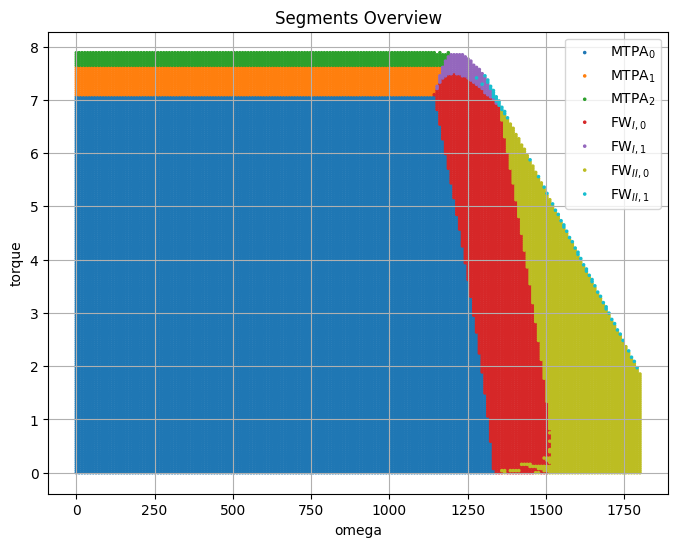

In [4]:
machine_data = grid_to_data(grid_result, k_skip=1)
plot_grid_segments(machine_data)